In [100]:
!pip install sympy numpy matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 15.8 MB/s  0:00:00 7.6 MB/s eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 71.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 31.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib] 6/7 [matplotlib]


In [27]:
import sympy as sp
from IPython.display import display


In [29]:
from sympy.matrices.expressions import MatrixSymbol, Identity
from sympy.matrices.expressions.diagonal import DiagonalMatrix

from sympy.tensor.array.expressions.array_expressions import (
    _array_tensor_product, _array_contraction
)
from sympy.tensor.array.expressions.from_array_to_matrix import (
    identify_removable_identity_matrices
)

k = sp.Symbol("k", integer=True, positive=True) #k是正整数
A = MatrixSymbol("A", k, k)# A是k*k的矩阵
B = MatrixSymbol("B", k, k)
I = Identity(k)#I是k*k的单位矩阵

D = DiagonalMatrix(MatrixSymbol("D", k, k))  #对角矩阵

# _array_tensor_product 
# 张量积就是把它们并排放一起，变成一个有 6 个指标的东西：
# T[i, j, p, q, r, s] = A[i,j]*B[p,q]*I[r,s]
# 6 个指标位置（从 0 开始编号
# 0,1 属于 A；2,3 属于 B；4,5 属于 I
_array_tensor_product(A, B, I)

#(1, 2) 配成一对：把 A 的第 2 个指标（列）和 B 的第 1 个指标（行）相连求和 
#(4, 5) 配成一对：把单位矩阵 I 的两个指标收缩（相当于 Tr(I) 或在该位置“啥也不影响”的结构）
cg = _array_contraction( _array_tensor_product(A, B, I), (1,2,4,5) )


expected = _array_contraction(_array_tensor_product(A, B), (1, 2))

print("cg      =", cg)
print("expected=", expected)

out = identify_removable_identity_matrices(cg)
print("out     =",out)

A_num = sp.Matrix([[1, 2], [3, 4]])
B_num = sp.Matrix([[5, 6], [7, 8]])
cg2 = cg.subs(k, 2)                 # 先把 Identity(k) 变成 Identity(2)
cg_num = cg2.subs({A: A_num, B: B_num}).doit()
display(cg_num),display(A_num)

cg      = ArrayContraction(ArrayTensorProduct(I, A, B), (0, 1, 3, 4))
expected= ArrayContraction(ArrayTensorProduct(A, B), (1, 2))
out     = ArrayContraction(ArrayTensorProduct(A, B), (1, 2))


ArrayContraction(ArrayTensorProduct(I, A, B), (0, 1, 3, 4))

Matrix([
[1, 2],
[3, 4]])

(None, None)

In [ ]:
import sympy as sp

# 这些是“数组表达式”层的内部构造器（测试里用的就是它们）
from sympy.tensor.array.expressions.array_expressions import (
    _array_tensor_product, _array_contraction
)

# 这个就是你测试用到的目标函数
from sympy.tensor.array.expressions.from_array_to_matrix import (
    identify_removable_identity_matrices
)

from sympy.matrices.expressions import MatrixSymbol, Identity
from sympy.matrices.expressions.diagonal import DiagonalMatrix


# --- 准备一些符号维度和矩阵符号 ---
k = sp.Symbol("k", integer=True, positive=True)

A = MatrixSymbol("A", k, k)
B = MatrixSymbol("B", k, k)
I = Identity(k)  # 注意：这是 MatrixExpr 层的 Identity(n)，不是 eye(n) 这种显式矩阵

#（你测试里出现但没用到的这行：）
D = DiagonalMatrix(MatrixSymbol("D", k, k))

# --- 构造测试表达式 ---
cg = _array_contraction(_array_tensor_product(A, B, I), (1, 2, 4, 5))
expected = _array_contraction(_array_tensor_product(A, B), (1, 2))

print("cg      =", cg)
print("expected=", expected)

# --- 关键：跑 identify_removable_identity_matrices 看它怎么把 I 消掉 ---
out = identify_removable_identity_matrices(cg)

print("out     =", out)
print("out == expected ?", sp.simplify(out == expected))

In [35]:
from sympy import expand, factor
from sympy import symbols
x, y = symbols('x y')
expr = x + 2*y

expanded_expr = expand(x*expr)
expanded_expr, factor(expanded_expr), display(expanded_expr)

x**2 + 2*x*y

(x**2 + 2*x*y, x*(x + 2*y), None)

In [41]:
from sympy import *
x, t, z, nu = symbols('x t z nu')

init_printing(use_unicode=True)

diff(sin(x)*exp(x), x) #求导



 x           x       
ℯ ⋅sin(x) + ℯ ⋅cos(x)

In [42]:
integrate(exp(x)*sin(x) + exp(x)*cos(x), x) #对x积分

 x       
ℯ ⋅sin(x)

In [43]:
integrate(sin(x**2), (x, -oo, oo))

√2⋅√π
─────
  2  

In [47]:
limit(sin(x)/x, x, 1), limit(sin(x)/x, x, 0) #极限

(sin(1), 1)

In [48]:
solve(x**2 - 2, x) #解方程

[-√2, √2]

In [50]:
latex(Integral(cos(x)**2, (x, 0, pi))) # latex 

'\\int\\limits_{0}^{\\pi} \\cos^{2}{\\left(x \\right)}\\, dx'

In [60]:
x = symbols('x')
expr = x + 1
# x = 2
print(expr),x, expr.subs('x', 2)

x + 1


(None, x, 3)

In [61]:
#Python syntax is that = does not represent equality in SymPy


In [62]:
Eq(x+1,3)

x + 1 = 3

In [64]:
eye(4)

⎡1  0  0  0⎤
⎢          ⎥
⎢0  1  0  0⎥
⎢          ⎥
⎢0  0  1  0⎥
⎢          ⎥
⎣0  0  0  1⎦

In [66]:
help(Matrix)

Help on class MutableDenseMatrix in module sympy.matrices.dense:

class MutableDenseMatrix(DenseMatrix, sympy.matrices.repmatrix.MutableRepMatrix)
 |  MutableDenseMatrix(*args, **kwargs)
 |  
 |  Method resolution order:
 |      MutableDenseMatrix
 |      DenseMatrix
 |      sympy.matrices.repmatrix.MutableRepMatrix
 |      sympy.matrices.repmatrix.RepMatrix
 |      sympy.matrices.matrixbase.MatrixBase
 |      sympy.printing.defaults.Printable
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  simplify(self, **kwargs)
 |      Applies simplify to the elements of a matrix in place.
 |      
 |      This is a shortcut for M.applyfunc(lambda x: simplify(x, ratio, measure))
 |      
 |      See Also
 |      ========
 |      
 |      sympy.simplify.simplify.simplify
 |  
 |  ----------------------------------------------------------------------
 |  Data and other attributes defined here:
 |  
 |  __annotations__ = {}
 |  
 |  -----------------------------------------------------

In [67]:
x = symbols('x')
expr = x + 1
expr, str(expr), srepr(expr)

(x + 1, 'x + 1', "Add(Symbol('x'), Integer(1))")

In [68]:

expr.func

sympy.core.add.Add

In [69]:
expr.args

(1, x)

In [70]:
expr.func(*expr.args)

x + 1

In [71]:
from sympy import Symbol, ask, Q
x = Symbol('x', integer=True)
print(ask(Q.rational(x)))  # 通常会推出 True：integer -> rational

True


In [72]:
from sympy import MatrixSymbol, ask, Q
A = MatrixSymbol('A', 3, 3)

# 没有任何假设时，通常不知道：
print(ask(Q.diagonal(A)))  # None

# 给假设：diagonal -> triangular, diagonal -> symmetric 等
# ask 会去查这些逻辑蕴含关系（facts）是否能推出别的性质
print(ask(Q.triangular(A), Q.diagonal(A)))  # True（对角必三角）

None
True


In [76]:
k = sp.Symbol("k", integer=True, positive=True)

A = MatrixSymbol("A", k, k)
B = MatrixSymbol("B", k, k)
I = Identity(k)  # 注意：这是 MatrixExpr 层的 Identity(n)，不是 eye(n) 这种显式矩阵

#（你测试里出现但没用到的这行：）
D = DiagonalMatrix(MatrixSymbol("D", k, k))
cg = _array_contraction(_array_tensor_product(A, B, D), (1, 2, 4, 5))
cg

ArrayContraction(ArrayTensorProduct(DiagonalMatrix(D), A, B), (0, 1, 3, 4))

In [78]:
help(A)

Help on MatrixSymbol in module sympy.matrices.expressions.matexpr object:

class MatrixSymbol(MatrixExpr)
 |  MatrixSymbol(name, n, m)
 |  
 |  Symbolic representation of a Matrix object
 |  
 |  Creates a SymPy Symbol to represent a Matrix. This matrix has a shape and
 |  can be included in Matrix Expressions
 |  
 |  Examples
 |  ========
 |  
 |  >>> from sympy import MatrixSymbol, Identity
 |  >>> A = MatrixSymbol('A', 3, 4) # A 3 by 4 Matrix
 |  >>> B = MatrixSymbol('B', 4, 3) # A 4 by 3 Matrix
 |  >>> A.shape
 |  (3, 4)
 |  >>> 2*A*B + Identity(3)
 |  I + 2*A*B
 |  
 |  Method resolution order:
 |      MatrixSymbol
 |      MatrixExpr
 |      sympy.core.expr.Expr
 |      sympy.core.basic.Basic
 |      sympy.printing.defaults.Printable
 |      sympy.core.evalf.EvalfMixin
 |      builtins.object
 |  
 |  Static methods defined here:
 |  
 |  __new__(cls, name, n, m)
 |      Create and return a new object.  See help(type) for accurate signature.
 |  
 |  -----------------------------

In [79]:
from sympy.tensor.array.expressions.array_expressions import (
    _EditArrayContraction, _array_contraction, _array_tensor_product
)
from sympy import Identity, MatrixSymbol
from sympy.matrices.expressions.diagonal import DiagonalMatrix

def debug_contraction(expr):
    ed = _EditArrayContraction(expr)
    print("=== args_with_ind ===")
    for n, awi in enumerate(ed.args_with_ind):
        elem = awi.element
        print(f"{n}: element={type(elem).__name__}  element_repr={elem}")
        print(f"   indices={awi.indices}")

    # 把所有出现过的“收缩索引 id”收集出来（排除 None）
    all_inds = []
    for awi in ed.args_with_ind:
        for ind in awi.indices:
            if ind is not None:
                all_inds.append(ind)

    print("\n=== count_args_with_index ===")
    for ind in sorted(set(all_inds), key=str):
        print(f"ind={ind}  count={ed.count_args_with_index(ind)}")

    return ed

In [80]:
k = 2
A = MatrixSymbol("A", k, k)
B = MatrixSymbol("B", k, k)
D = DiagonalMatrix(MatrixSymbol("D", k, k))

# 注意：I 要用 sympy 的 Identity(k)（不是 MatrixSymbol）
I = Identity(k)

cg = _array_contraction(_array_tensor_product(A, B, D), (1, 2, 4, 5))
ed = debug_contraction(cg)

=== args_with_ind ===
0: element=DiagonalMatrix  element_repr=DiagonalMatrix(D)
   indices=[0, 0]
1: element=MatrixSymbol  element_repr=A
   indices=[None, 0]
2: element=MatrixSymbol  element_repr=B
   indices=[0, None]

=== count_args_with_index ===
ind=0  count=3


In [84]:
from sympy import I
from sympy.abc import n
# 对参数化 的 虚数 做 实数化判定

assert imageset(Lambda(n, n + (n - 1)*(n + 1)*I), S.Integers).intersect(S.Reals) == \
        FiniteSet(-1, 1)

In [85]:
imageset(Lambda(n, n + (n - 1)*(n + 1)*I), S.Integers)

{n + ⅈ⋅(n - 1)⋅(n + 1) │ n ∊ ℤ}

In [86]:
S.Reals

ℝ

In [87]:
FiniteSet(-1, 1)

{-1, 1}

In [88]:
Lambda(n, n + (n - 1)*(n + 1)*I)

n ↦ n + ⅈ⋅(n - 1)⋅(n + 1)

In [91]:
def test_imageset_intersect_real():
    from sympy import I
    from sympy.abc import n
    # Original: n + (n - 1)*(n + 1)*I  (degree 2 polynomial)
    # Stress: High-degree polynomial with nested operations
    assert imageset(Lambda(n, n + (n - 1)*(n + 1)*(n**98 + 3*n**50 - 2)*I), Range(-1000, 1000)).intersect(S.Reals)

    # Original: -I*(I*(2*pi*n - pi/4) + log(Abs(sqrt(-I))))
    # Stress: Deeply nested transcendental expression with multiple operations
    s = ImageSet(Lambda(n, -I*(I*(2*pi*n**3 - pi/4) + log(Abs(sqrt(-I)*sin(n) + exp(1/n))) + cos(log(n+1)))), Range(-500, 500))
test_imageset_intersect_real()

In [97]:
@image_comparison(['proportional_colorbars.png'], remove_text=True,
                  style='mpl20')
def test_proportional_colorbars():

    x = y = np.arange(-3.0, 3.01, 0.025)
    X, Y = np.meshgrid(x, y)
    Z1 = np.exp(-X**2 - Y**2)
    Z2 = np.exp(-(X - 1)**2 - (Y - 1)**2)
    Z = (Z1 - Z2) * 2

    levels = [-1.25, -0.5, -0.125, 0.125, 0.5, 1.25]
    cmap = mcolors.ListedColormap(
        ['0.3', '0.5', 'white', 'lightblue', 'steelblue'])
    cmap.set_under('darkred')
    cmap.set_over('crimson')
    norm = mcolors.BoundaryNorm(levels, cmap.N)

    extends = ['neither', 'both']
    spacings = ['uniform', 'proportional']
    fig, axs = plt.subplots(2, 2)
    for i in range(2):
        for j in range(2):
            CS3 = axs[i, j].contourf(X, Y, Z, levels, cmap=cmap, norm=norm,
                                     extend=extends[i])
            fig.colorbar(CS3, spacing=spacings[j], ax=axs[i, j])

NameError: name 'image_comparison' is not defined

(array([[-3.   , -2.975, -2.95 , ...,  2.95 ,  2.975,  3.   ],
        [-3.   , -2.975, -2.95 , ...,  2.95 ,  2.975,  3.   ],
        [-3.   , -2.975, -2.95 , ...,  2.95 ,  2.975,  3.   ],
        ...,
        [-3.   , -2.975, -2.95 , ...,  2.95 ,  2.975,  3.   ],
        [-3.   , -2.975, -2.95 , ...,  2.95 ,  2.975,  3.   ],
        [-3.   , -2.975, -2.95 , ...,  2.95 ,  2.975,  3.   ]],
       shape=(241, 241)),
 array([[-3.   , -3.   , -3.   , ..., -3.   , -3.   , -3.   ],
        [-2.975, -2.975, -2.975, ..., -2.975, -2.975, -2.975],
        [-2.95 , -2.95 , -2.95 , ..., -2.95 , -2.95 , -2.95 ],
        ...,
        [ 2.95 ,  2.95 ,  2.95 , ...,  2.95 ,  2.95 ,  2.95 ],
        [ 2.975,  2.975,  2.975, ...,  2.975,  2.975,  2.975],
        [ 3.   ,  3.   ,  3.   , ...,  3.   ,  3.   ,  3.   ]],
       shape=(241, 241)))

In [107]:
help(Symbol)

NameError: name 'Symbols' is not defined

In [108]:
x,h = Symbol("x"), Symbol("h")
limit(((x + h)**3 - x**3)/h, h, 0) 

In [109]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [112]:
x = y = np.arange(-3.0, 3.01, 0.025)
len(x)


In [114]:
X, Y = np.meshgrid(x, y)

In [113]:
help(np.meshgrid)

Help on _ArrayFunctionDispatcher in module numpy:

meshgrid(*xi, copy=True, sparse=False, indexing='xy')
    Return a tuple of coordinate matrices from coordinate vectors.
    
    Make N-D coordinate arrays for vectorized evaluations of
    N-D scalar/vector fields over N-D grids, given
    one-dimensional coordinate arrays x1, x2,..., xn.
    
    Parameters
    ----------
    x1, x2,..., xn : array_like
        1-D arrays representing the coordinates of a grid.
    indexing : {'xy', 'ij'}, optional
        Cartesian ('xy', default) or matrix ('ij') indexing of output.
        See Notes for more details.
    sparse : bool, optional
        If True the shape of the returned coordinate array for dimension *i*
        is reduced from ``(N1, ..., Ni, ... Nn)`` to
        ``(1, ..., 1, Ni, 1, ..., 1)``.  These sparse coordinate grids are
        intended to be use with :ref:`basics.broadcasting`.  When all
        coordinates are used in an expression, broadcasting still leads to a
      

In [115]:
Z1 = np.exp(-X**2 - Y**2)
Z2 = np.exp(-(X - 1)**2 - (Y - 1)**2)
Z = (Z1 - Z2) * 2
Z

array([[ 3.04599342e-08,  3.53672816e-08,  4.10139437e-08, ...,
         3.59915557e-08,  3.08143049e-08,  2.63376522e-08],
       [ 3.53672816e-08,  4.10652432e-08,  4.76216291e-08, ...,
         4.14911034e-08,  3.55076995e-08,  3.03354609e-08],
       [ 4.10139437e-08,  4.76216291e-08,  5.52247930e-08, ...,
         4.77509785e-08,  4.08463455e-08,  3.48795768e-08],
       ...,
       [ 3.59915557e-08,  4.14911034e-08,  4.77509785e-08, ...,
        -9.95855618e-04, -9.02780992e-04, -8.17382828e-04],
       [ 3.08143049e-08,  3.55076995e-08,  4.08463455e-08, ...,
        -9.02780992e-04, -8.18405195e-04, -7.40988429e-04],
       [ 2.63376522e-08,  3.03354609e-08,  3.48795768e-08, ...,
        -8.17382828e-04, -7.40988429e-04, -6.70894796e-04]],
      shape=(241, 241))

In [116]:
    levels = [-1.25, -0.5, -0.125, 0.125, 0.5, 1.25]

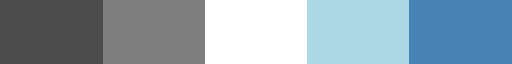

In [118]:
cmap = mcolors.ListedColormap(
    ['0.3', '0.5', 'white', 'lightblue', 'steelblue'])
cmap

In [119]:
help(mcolors.ListedColormap)

Help on class ListedColormap in module matplotlib.colors:

class ListedColormap(Colormap)
 |  ListedColormap(colors, name='from_list', N=None)
 |  
 |  Colormap object generated from a list of colors.
 |  
 |  This may be most useful when indexing directly into a colormap,
 |  but it can also be used to generate special colormaps for ordinary
 |  mapping.
 |  
 |  Parameters
 |  ----------
 |  colors : list, array
 |      Sequence of Matplotlib color specifications (color names or RGB(A)
 |      values).
 |  name : str, optional
 |      String to identify the colormap.
 |  N : int, optional
 |      Number of entries in the map. The default is *None*, in which case
 |      there is one colormap entry for each element in the list of colors.
 |      If ::
 |  
 |          N < len(colors)
 |  
 |      the list will be truncated at *N*. If ::
 |  
 |          N > len(colors)
 |  
 |      the list will be extended by repetition.
 |  
 |  Method resolution order:
 |      ListedColormap
 |    

In [121]:
cmap.set_under('darkred')
cmap.set_over('crimson')
norm = mcolors.BoundaryNorm(levels, cmap.N)

extends = ['neither', 'both']
spacings = ['uniform', 'proportional']

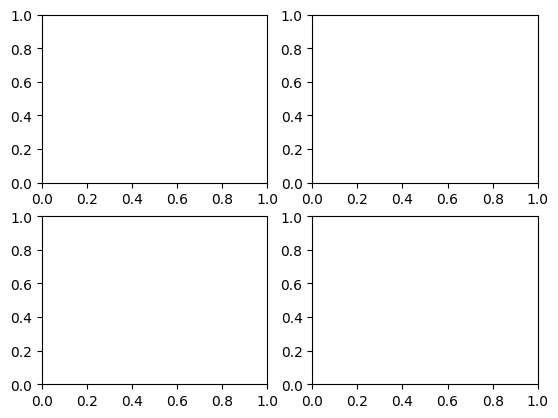

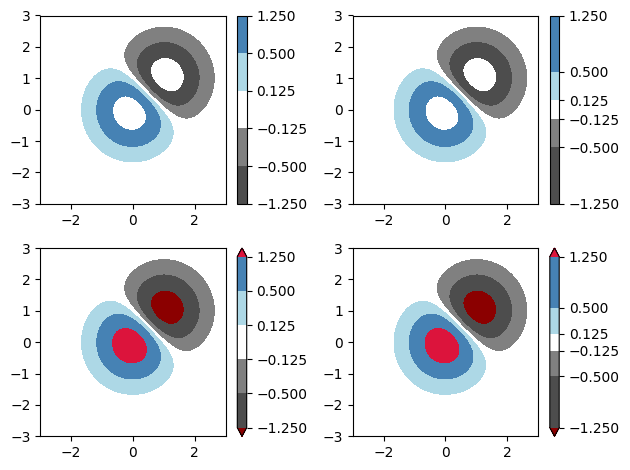

In [126]:
fig, axs = plt.subplots(2, 2)
for i in range(2):
    for j in range(2):
        CS3 = axs[i, j].contourf(X, Y, Z, levels, cmap=cmap, norm=norm,
                                 extend=extends[i])
        fig.colorbar(CS3, spacing=spacings[j], ax=axs[i, j])
plt.tight_layout()
plt.show()

In [130]:
! pip install astropy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4/6.4 MB 8.7 MB/s  0:00:01m 5.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 31.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [astropy]━━━━━━━━━━ 2/3 [astropy]


In [132]:
from astropy import constants as const
from astropy import find_api_page
# 计算地球到太阳的平均距离
# distance_to_sun = const.auprint(f"地球到太阳的平均距离：{distance_to_sun} 米")
find_api_page(const)

'https://docs.astropy.org/en/v6.1.7/constants/index.html#module-astropy.constants'

In [133]:
const.G

<<class 'astropy.constants.codata2018.CODATA2018'> name='Gravitational constant' value=6.6743e-11 uncertainty=1.5e-15 unit='m3 / (kg s2)' reference='CODATA 2018'>

In [128]:
!pip install sympy hypothesis 

  Using cached hypothesis-6.151.9-py3-none-any.whl.metadata (5.6 kB)
  Using cached sortedcontainers-2.4.0-py2.py3-none-any.whl.metadata (10 kB)
Using cached hypothesis-6.151.9-py3-none-any.whl (529 kB)
Using cached sortedcontainers-2.4.0-py2.py3-none-any.whl (29 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [hypothesis]


In [129]:
from typing import Any

from hypothesis import given, settings
import hypothesis.strategies as st
from sympy import Integer, Rational, Symbol, diff, limit, simplify


x: Any = Symbol("x")
h: Any = Symbol("h")


@settings(max_examples=300, deadline=None)
@given(
    coeffs=st.lists(st.integers(-8, 8), min_size=1, max_size=8),
    eval_point=st.integers(-5, 5),
)
def test_limit_diff_quotient_polynomial_fuzz(coeffs, eval_point):
    polynomial: Any = Integer(0)
    for index, coef in enumerate(coeffs):
        term: Any = Integer(coef) * x**index
        polynomial = polynomial + term

    lhs: Any = limit((polynomial.subs(x, x + h) - polynomial) / h, h, 0)
    rhs: Any = diff(polynomial, x)

    assert simplify(lhs - rhs) == 0
    assert simplify(lhs.subs(x, eval_point) - rhs.subs(x, eval_point)) == 0

In [2]:
import dis
dis.dis(
"""
a = 1 
print(a)
""")


  2           0 LOAD_CONST               0 (1)
              2 STORE_NAME               0 (a)

  3           4 LOAD_NAME                1 (print)
              6 LOAD_NAME                0 (a)
              8 CALL_FUNCTION            1
             10 POP_TOP
             12 LOAD_CONST               1 (None)
             14 RETURN_VALUE


In [3]:
import inspect

In [4]:
help(inspect)

Help on module inspect:

NAME
    inspect - Get useful information from live Python objects.

MODULE REFERENCE
    https://docs.python.org/3.10/library/inspect.html
    
    The following documentation is automatically generated from the Python
    source files.  It may be incomplete, incorrect or include features that
    are considered implementation detail and may vary between Python
    implementations.  When in doubt, consult the module reference at the
    location listed above.

DESCRIPTION
    This module encapsulates the interface provided by the internal special
    attributes (co_*, im_*, tb_*, etc.) in a friendlier fashion.
    It also provides some help for examining source code and class layout.
    
    Here are some of the useful functions provided by this module:
    
        ismodule(), isclass(), ismethod(), isfunction(), isgeneratorfunction(),
            isgenerator(), istraceback(), isframe(), iscode(), isbuiltin(),
            isroutine() - check object types
   

In [7]:
print(
 "@seed(12345)\n@settings(max_examples=25, deadline=None, derandomize=True, database=None, phases=[Phase.generate], suppress_health_check=[HealthCheck.too_slow])\n@given(st.integers(min_value=1, max_value=4), st.integers(min_value=1, max_value=4), st.integers(min_value=0, max_value=100))\ndef test_iforest_parallel_regression_fuzz(n_jobs1, n_jobs2, random_state):\n    from sklearn.ensemble import IsolationForest\n    from sklearn.datasets import make_regression\n    from sklearn.model_selection import train_test_split\n    import numpy as np\n    \n    # Generate synthetic regression data to avoid dependency on deprecated boston dataset\n    X, y = make_regression(n_samples=100, n_features=10, noise=0.1, random_state=random_state)\n    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)\n    \n    # Fit with n_jobs1\n    ensemble = IsolationForest(n_jobs=n_jobs1, random_state=random_state).fit(X_train)\n    \n    # Predict with n_jobs1\n    y1 = ensemble.predict(X_test)\n    \n    # Change n_jobs and predict again\n    ensemble.set_params(n_jobs=n_jobs2)\n    y2 = ensemble.predict(X_test)\n    \n    # Assert predictions are almost equal\n    np.testing.assert_array_almost_equal(y1, y2)\n    \n    # Fit fresh model with n_jobs=1\n    ensemble1 = IsolationForest(n_jobs=1, random_state=random_state).fit(X_train)\n    y3 = ensemble1.predict(X_test)\n    \n    # Assert consistency with first prediction\n    np.testing.assert_array_almost_equal(y1, y3)"
)

@seed(12345)
@settings(max_examples=25, deadline=None, derandomize=True, database=None, phases=[Phase.generate], suppress_health_check=[HealthCheck.too_slow])
@given(st.integers(min_value=1, max_value=4), st.integers(min_value=1, max_value=4), st.integers(min_value=0, max_value=100))
def test_iforest_parallel_regression_fuzz(n_jobs1, n_jobs2, random_state):
    from sklearn.ensemble import IsolationForest
    from sklearn.datasets import make_regression
    from sklearn.model_selection import train_test_split
    import numpy as np
    
    # Generate synthetic regression data to avoid dependency on deprecated boston dataset
    X, y = make_regression(n_samples=100, n_features=10, noise=0.1, random_state=random_state)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)
    
    # Fit with n_jobs1
    ensemble = IsolationForest(n_jobs=n_jobs1, random_state=random_state).fit(X_train)
    
    # Predict with n_jobs1
    y1 = ensemble.pre

In [12]:
numbers = range(0,6)
for i in range(0,len(numbers),2):
    print(numbers[:i])

range(0, 0)
range(0, 2)
range(0, 4)


In [14]:
import hotspots


ModuleNotFoundError: No module named 'hotspots'

In [15]:
!pip install snakeviz
# snakeviz prof.out

In [16]:
from typing import Any

from hypothesis import given, settings
import hypothesis.strategies as st
from sympy import Integer, Rational, Symbol, diff, limit, simplify


x: Any = Symbol("x")
h: Any = Symbol("h")


@settings(max_examples=300, deadline=None)
@given(
    coeffs=st.lists(st.integers(-8, 8), min_size=1, max_size=8),
    eval_point=st.integers(-5, 5),
)
def test_limit_diff_quotient_polynomial_fuzz(coeffs, eval_point):
    polynomial: Any = Integer(0)
    for index, coef in enumerate(coeffs):
        term: Any = Integer(coef) * x**index
        polynomial = polynomial + term

    lhs: Any = limit((polynomial.subs(x, x + h) - polynomial) / h, h, 0)
    rhs: Any = diff(polynomial, x)

    assert simplify(lhs - rhs) == 0
    assert simplify(lhs.subs(x, eval_point) - rhs.subs(x, eval_point)) == 0

In [23]:
%prun -D prof.out  test_limit_diff_quotient_polynomial_fuzz()

 
*** Profile stats marshalled to file 'prof.out'.


         33492275 function calls (30315585 primitive calls) in 6.828 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
1155507/55323    0.331    0.000    6.130    0.000 cache.py:69(wrapper)
698793/678443    0.221    0.000    0.594    0.000 sympify.py:124(sympify)
59123/4646    0.217    0.000    1.757    0.000 powsimp.py:18(powsimp)
11951/5685    0.197    0.000    0.820    0.000 assumptions.py:509(_ask)
4349088/4209906    0.193    0.000    0.234    0.000 {built-in method builtins.isinstance}
474531/458996    0.190    0.000    0.315    0.000 basic.py:497(__eq__)
    75093    0.160    0.000    0.484    0.000 basic.py:2153(is_same)
33270/17802    0.147    0.000    0.702    0.000 radsimp.py:22(collect)
186409/105352    0.128    0.000    0.649    0.000 sorting.py:202(ordered)
77018/27858    0.113    0.000    0.307    0.000 sorting.py:10(default_sort_key)
1427881/1316570    0.113    0.000    0.148    0.000 basic.py:315(__hash__)
853

In [ ]:
!snakeviz prof.out

In [26]:
def fibonacci(n):
    stack = [n]
    result = 0
    while stack:
        current = stack.pop(0)
        if current <= 0:
            result += 0
        elif current == 1:
            result += 1
        else:
            stack.append(current - 1)
            stack.append(current - 2)
    return result

In [30]:
from collections import deque
def fibonacci(n):
    stack = deque([n])
    result = 0
    while stack:
        current = stack.popleft()
        if current <= 0:
            result += 0
        elif current == 1:
            result += 1
        else:
            stack.append(current - 1)
            stack.append(current - 2)
    return result
fibonacci(27)

196418

In [31]:
%prun -D prof_fib.out  fibonacci(27)
!snakeviz prof_fib.out

 
*** Profile stats marshalled to file 'prof_fib.out'.
snakeviz web server started on 127.0.0.1:8080; enter Ctrl-C to exit
http://127.0.0.1:8080/snakeviz/%2FUsers%2Fcoffeecat%2FDesktop%2FCoffee-Kitty.github.io%2Fdocs%2Flife%2Fdiary%2Fprof_fib.out
^C

Bye!


         1271245 function calls in 0.130 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.099    0.099    0.130    0.130 514355889.py:2(fibonacci)
   635620    0.017    0.000    0.017    0.000 {method 'append' of 'collections.deque' objects}
   635621    0.015    0.000    0.015    0.000 {method 'popleft' of 'collections.deque' objects}
        1    0.000    0.000    0.130    0.130 {built-in method builtins.exec}
        1    0.000    0.000    0.130    0.130 <string>:1(<module>)
        1    0.000    0.000    0.000    0.000 {method 'disable' of '_lsprof.Profiler' objects}

In [32]:
import profile
import sys


def profiler(frame, event, arg):
    print('PROFILER: %r %r' % (event, arg))


sys.setprofile(profiler)


# 计算斐波那契数列的简单（也是非常低效的）示例
def fib(n):
    if n == 0:
        return 0
    elif n == 1:
        return 1
    else:
        return fib(n - 1) + fib(n - 2)


def fib_seq(n):
    seq = []
    if n > 0:
        seq.extend(fib_seq(n - 1))
    seq.append(fib(n))
    return seq


print(fib_seq(2))

PROFILER: 'return' None
PROFILER: 'return' False
PROFILER: 'call' None
PROFILER: 'call' None
PROFILER: 'call' None
PROFILER: 'return' True
PROFILER: 'return' True
PROFILER: 'call' None
PROFILER: 'return' True
PROFILER: 'return' True
PROFILER: 'c_call' <built-in function getattr>
PROFILER: 'c_return' <built-in function getattr>
PROFILER: 'call' None
PROFILER: 'call' None
PROFILER: 'c_call' <built-in function getattr>
PROFILER: 'c_return' <built-in function getattr>
PROFILER: 'return' None
PROFILER: 'return' <contextlib._GeneratorContextManager object at 0x1089e2710>
PROFILER: 'call' None
PROFILER: 'c_call' <built-in function next>
PROFILER: 'call' None
PROFILER: 'return' None
PROFILER: 'c_return' <built-in function next>
PROFILER: 'return' None
PROFILER: 'call' None
PROFILER: 'c_call' <built-in function compile>
PROFILER: 'c_return' <built-in function compile>
PROFILER: 'return' <code object <module> at 0x1089c9630, file "/var/folders/_1/bny2r6_91qv_7_6fdv2w9cy80000gn/T/ipykernel_17269/

In [33]:
import re

PROFILER: 'c_return' <built-in method set of _contextvars.ContextVar object at 0x105426750>
PROFILER: 'return' <Token var=<ContextVar name='parent_header' at 0x105426750> at 0x10831e9c0>
PROFILER: 'return' None
PROFILER: 'call' None
PROFILER: 'call' None
PROFILER: 'c_call' <built-in function isinstance>
PROFILER: 'c_return' <built-in function isinstance>
PROFILER: 'return' {'date': datetime.datetime(2026, 3, 17, 9, 49, 14, 736000, tzinfo=tzutc()), 'msg_id': '215fba12-5de4-42cd-9bb3-84fc7ad909af', 'msg_type': 'execute_request', 'session': '7d739f37-e8fd-4bd0-b40d-8c7039284cdf', 'username': '', 'version': '5.2'}
PROFILER: 'call' None
PROFILER: 'c_call' <built-in method set of _contextvars.ContextVar object at 0x105508c20>
PROFILER: 'c_return' <built-in method set of _contextvars.ContextVar object at 0x105508c20>
PROFILER: 'return' <Token var=<ContextVar name='parent_header' at 0x105508c20> at 0x10831e9c0>
PROFILER: 'return' None
PROFILER: 'return' None
PROFILER: 'return' None
PROFILER: '

In [34]:
re.compile("foo|bar")

PROFILER: 'c_return' <built-in method set of _contextvars.ContextVar object at 0x105426750>
PROFILER: 'return' <Token var=<ContextVar name='parent_header' at 0x105426750> at 0x1086b4ac0>
PROFILER: 'return' None
PROFILER: 'call' None
PROFILER: 'call' None
PROFILER: 'c_call' <built-in function isinstance>
PROFILER: 'c_return' <built-in function isinstance>
PROFILER: 'return' {'date': datetime.datetime(2026, 3, 17, 9, 49, 16, 470000, tzinfo=tzutc()), 'msg_id': '2fdddad7-3c3a-4326-bfdb-30eee5681531', 'msg_type': 'execute_request', 'session': '7d739f37-e8fd-4bd0-b40d-8c7039284cdf', 'username': '', 'version': '5.2'}
PROFILER: 'call' None
PROFILER: 'c_call' <built-in method set of _contextvars.ContextVar object at 0x105508c20>
PROFILER: 'c_return' <built-in method set of _contextvars.ContextVar object at 0x105508c20>
PROFILER: 'return' <Token var=<ContextVar name='parent_header' at 0x105508c20> at 0x10831d180>
PROFILER: 'return' None
PROFILER: 'return' None
PROFILER: 'return' None
PROFILER: '

re.compile(r'foo|bar', re.UNICODE)

PROFILER: 'c_return' <built-in method acquire of _thread.lock object at 0x10873d800>
PROFILER: 'call' None
PROFILER: 'c_call' <built-in method acquire of _thread.lock object at 0x10818cf40>
PROFILER: 'c_return' <built-in method acquire of _thread.lock object at 0x10818cf40>
PROFILER: 'return' None
PROFILER: 'return' True
PROFILER: 'call' None
PROFILER: 'c_call' <built-in method __exit__ of _thread.lock object at 0x10818cf40>
PROFILER: 'c_return' <built-in method __exit__ of _thread.lock object at 0x10818cf40>
PROFILER: 'return' None
PROFILER: 'return' True
PROFILER: 'return' None
PROFILER: 'call' None
PROFILER: 'call' None
PROFILER: 'call' None
PROFILER: 'return' True
PROFILER: 'call' None
PROFILER: 'c_call' <built-in method acquire of _thread.lock object at 0x1054ee080>
PROFILER: 'c_return' <built-in method acquire of _thread.lock object at 0x1054ee080>
PROFILER: 'return' None
PROFILER: 'return' True
PROFILER: 'call' None
PROFILER: 'return' 6148321280
PROFILER: 'call' None
PROFILER: '

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



PROFILER: 'c_return' <built-in method acquire of _thread.lock object at 0x108814b00>
PROFILER: 'call' None
PROFILER: 'c_call' <built-in method acquire of _thread.lock object at 0x108816080>
PROFILER: 'c_return' <built-in method acquire of _thread.lock object at 0x108816080>
PROFILER: 'return' None
PROFILER: 'return' True
PROFILER: 'call' None
PROFILER: 'c_call' <built-in method __exit__ of _thread.lock object at 0x108816080>
PROFILER: 'c_return' <built-in method __exit__ of _thread.lock object at 0x108816080>
PROFILER: 'return' None
PROFILER: 'return' True
PROFILER: 'return' None
PROFILER: 'call' None
PROFILER: 'call' None
PROFILER: 'call' None
PROFILER: 'return' True
PROFILER: 'call' None
PROFILER: 'c_call' <built-in method acquire of _thread.lock object at 0x1054ee080>
PROFILER: 'c_return' <built-in method acquire of _thread.lock object at 0x1054ee080>
PROFILER: 'return' None
PROFILER: 'return' True
PROFILER: 'call' None
PROFILER: 'return' 6148321280
PROFILER: 'call' None
PROFILER: '

NameError: name 'foo' is not defined

PROFILER: 'c_return' <built-in method acquire of _thread.lock object at 0x108816080>
PROFILER: 'call' None
PROFILER: 'c_call' <built-in method acquire of _thread.lock object at 0x10824d940>
PROFILER: 'c_return' <built-in method acquire of _thread.lock object at 0x10824d940>
PROFILER: 'return' None
PROFILER: 'return' True
PROFILER: 'call' None
PROFILER: 'c_call' <built-in method __exit__ of _thread.lock object at 0x10824d940>
PROFILER: 'c_return' <built-in method __exit__ of _thread.lock object at 0x10824d940>
PROFILER: 'return' None
PROFILER: 'return' True
PROFILER: 'return' None
PROFILER: 'c_call' <built-in method replace of bytes object at 0x105a46970>
PROFILER: 'c_return' <built-in method replace of bytes object at 0x105a46970>
PROFILER: 'call' None
PROFILER: 'call' None
PROFILER: 'call' None
PROFILER: 'return' <jupyter_client.session.Session object at 0x1054e4400>
PROFILER: 'return' <jupyter_client.session.Session object at 0x1054e4400>
PROFILER: 'call' None
PROFILER: 'return' <jup